In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load the dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Display the first 5 rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [4]:
# Check for missing values
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [5]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
# Display all column names
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [7]:
# Fill missing values using the most frequent value (mode)

df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

In [8]:
# Check missing values again

df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [9]:
# Convert categorical columns into numbers

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [10]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


In [11]:
# Correlation with Exam Score

correlation = df.corr()

correlation["Exam_Score"].sort_values(ascending=False)

,Exam_Score
Exam_Score,1.000000
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Peer_Influence,0.100217
Distance_from_Home,0.088934
Extracurricular_Activities,0.064382
Internet_Access,0.051475
Parental_Education_Level,0.044574


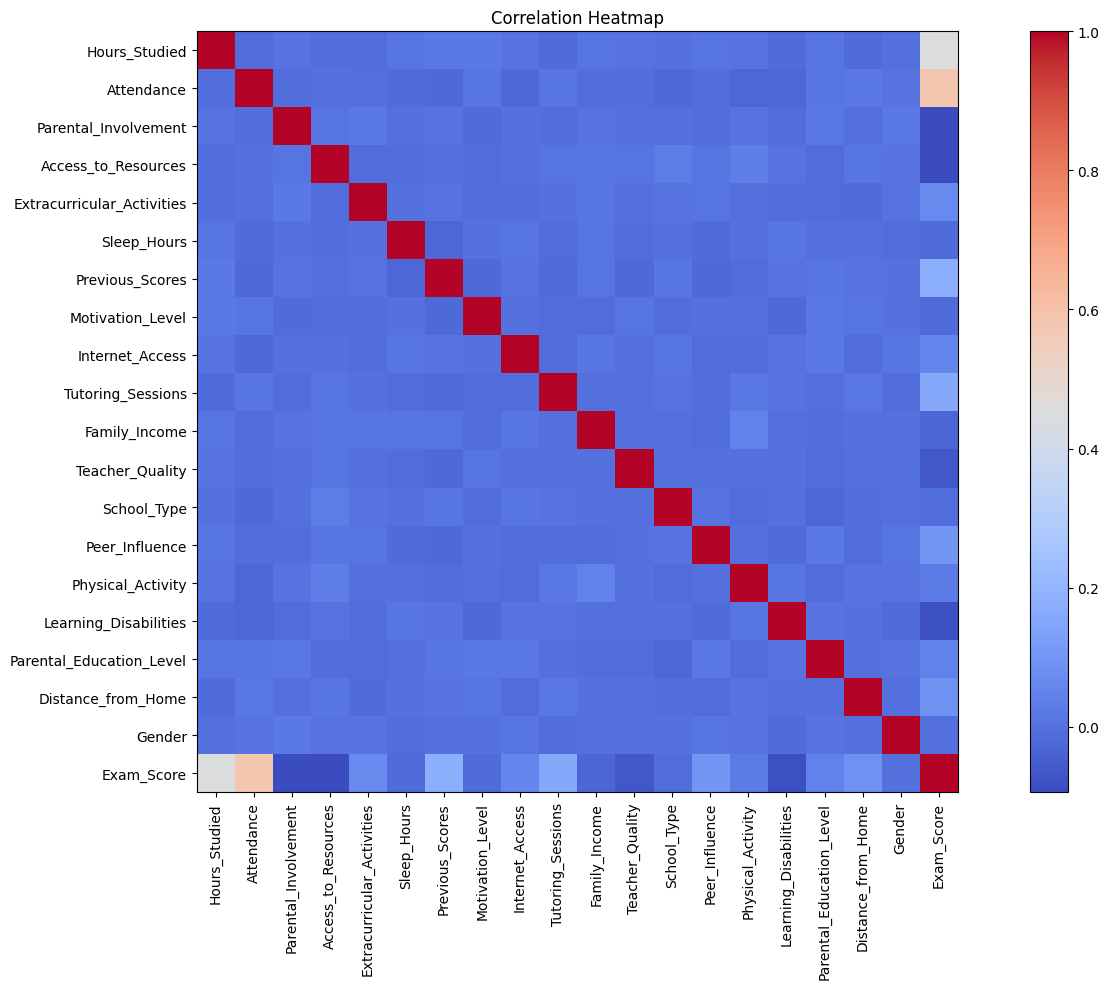

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plt.imshow(df.corr(), cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)

plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("heatmap.png", dpi=300)

plt.show()

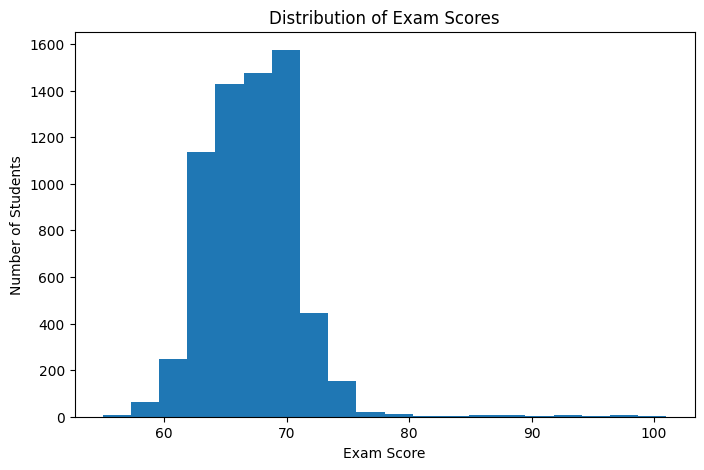

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Exam_Score"], bins=20)

plt.xlabel("Exam Score")

plt.ylabel("Number of Students")

plt.title("Distribution of Exam Scores")

plt.savefig("exam_score_histogram.png", dpi=300)

plt.show()

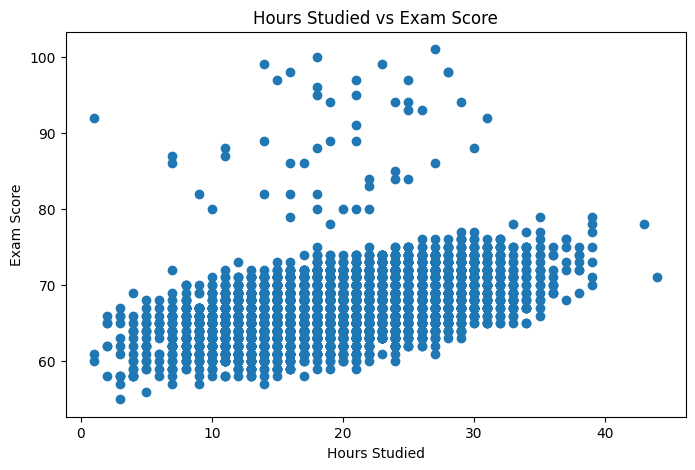

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(df["Hours_Studied"], df["Exam_Score"])

plt.xlabel("Hours Studied")

plt.ylabel("Exam Score")

plt.title("Hours Studied vs Exam Score")

plt.savefig("hours_vs_exam.png", dpi=300)

plt.show()

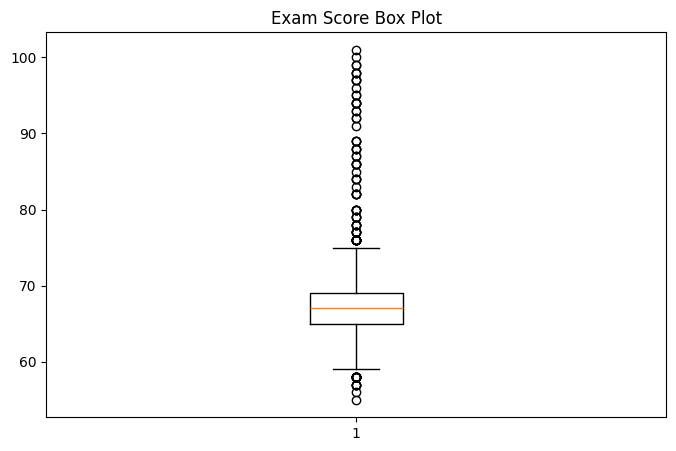

In [15]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Exam_Score"])

plt.title("Exam Score Box Plot")

plt.savefig("boxplot.png", dpi=300)

plt.show()

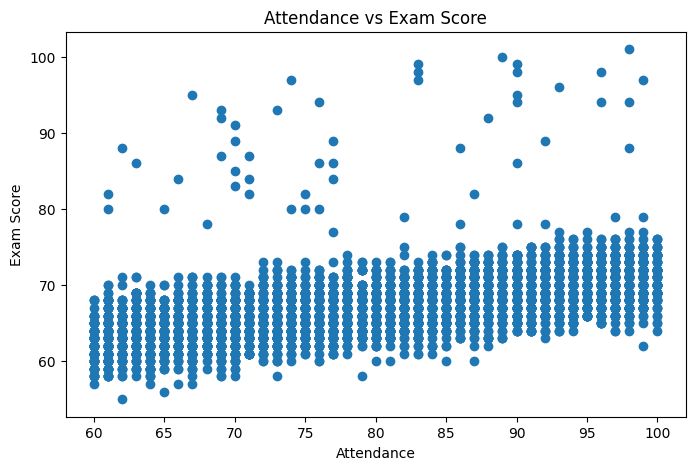

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df["Attendance"], df["Exam_Score"])

plt.xlabel("Attendance")

plt.ylabel("Exam Score")

plt.title("Attendance vs Exam Score")

plt.savefig("attendance_vs_exam.png", dpi=300)

plt.show()

In [17]:
# Features (X) and Target (y)

X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

# Split into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (5285, 19)
Testing Set : (1322, 19)


In [18]:
# Train Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [19]:
# Predict using Linear Regression

linear_predictions = linear_model.predict(X_test)

print(linear_predictions[:10])

[65.21661267 67.44841105 69.82970337 67.28780452 66.75815888 68.12362991
 71.34655218 67.88775689 70.61053195 69.73680481]


In [20]:
# Evaluate Linear Regression

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = linear_mse ** 0.5
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-" * 35)
print(f"MAE  : {linear_mae:.2f}")
print(f"MSE  : {linear_mse:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Results
-----------------------------------
MAE  : 1.02
MSE  : 4.40
RMSE : 2.10
R²   : 0.6888


In [21]:
# Train Decision Tree

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [22]:
tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_mse = mean_squared_error(y_test, tree_predictions)
tree_rmse = tree_mse ** 0.5
tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree Results")
print("-" * 35)
print(f"MAE  : {tree_mae:.2f}")
print(f"MSE  : {tree_mse:.2f}")
print(f"RMSE : {tree_rmse:.2f}")
print(f"R²   : {tree_r2:.4f}")

Decision Tree Results
-----------------------------------
MAE  : 1.73
MSE  : 10.88
RMSE : 3.30
R²   : 0.2305


In [23]:
# Train Random Forest

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [24]:
forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_mse = mean_squared_error(y_test, forest_predictions)
forest_rmse = forest_mse ** 0.5
forest_r2 = r2_score(y_test, forest_predictions)

print("Random Forest Results")
print("-" * 35)
print(f"MAE  : {forest_mae:.2f}")
print(f"MSE  : {forest_mse:.2f}")
print(f"RMSE : {forest_rmse:.2f}")
print(f"R²   : {forest_r2:.4f}")

Random Forest Results
-----------------------------------
MAE  : 1.13
MSE  : 4.88
RMSE : 2.21
R²   : 0.6546


In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R² Score": [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

comparison.sort_values("R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.015549,2.097445,0.688769
2,Random Forest,1.131399,2.209454,0.654640
1,Decision Tree,1.729198,3.298099,0.230463


In [26]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Attendance,0.380088
0,Hours_Studied,0.242312
6,Previous_Scores,0.091586
9,Tutoring_Sessions,0.035263
5,Sleep_Hours,0.030049
14,Physical_Activity,0.028412
3,Access_to_Resources,0.027855
2,Parental_Involvement,0.027454
13,Peer_Influence,0.018911
10,Family_Income,0.018383


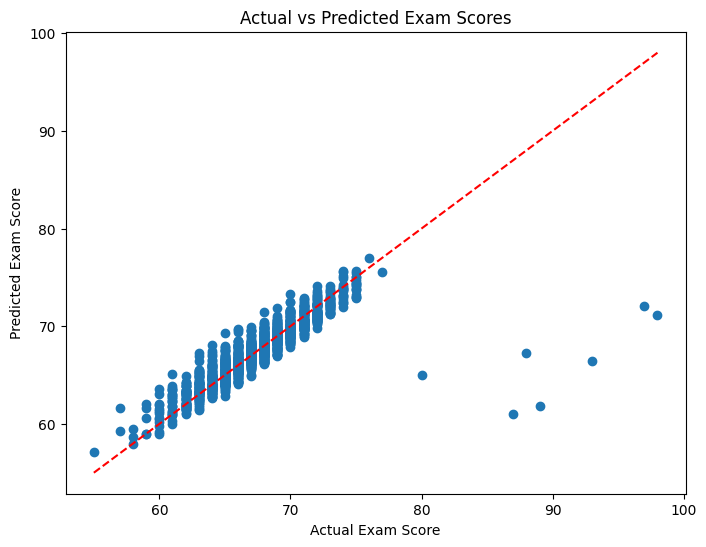

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, linear_predictions)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

In [28]:
import joblib

joblib.dump(linear_model, "student_performance_model.pkl")

['student_performance_model.pkl']

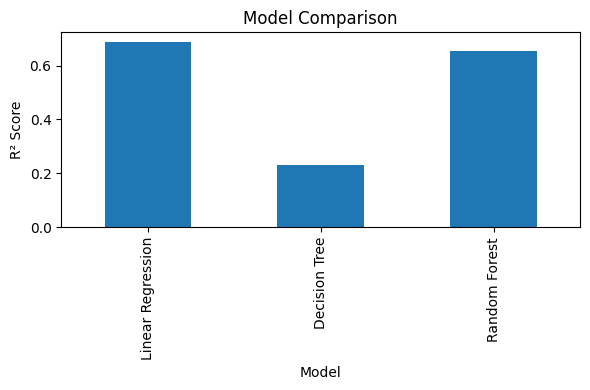

In [29]:
comparison.plot(
    x="Model",
    y="R² Score",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("R² Score")
plt.title("Model Comparison")

plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300)

plt.show()